# SentimentScope: Sentiment Analysis using Transformers!

### Imports + Seed + Device

In [312]:
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import os
import pandas as pd
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)





Device: cpu
Torch: 2.10.0+cu128


### Define dataset paths + verify they exist

I am setting the 4 folder paths (train pos/neg, test pos/neg) and make sure they exist.I have to be 100% sure the notebook is pointing to the right folders. This prevents silent bugs later.

In [313]:
import os
import pandas as pd

train_pos_path = "../aclImdb/train/pos"
train_neg_path = "../aclImdb/train/neg"
test_pos_path  = "../aclImdb/test/pos"
test_neg_path  = "../aclImdb/test/neg"

for p in [ train_pos_path, train_neg_path, test_pos_path, test_neg_path]:
    assert os.path.exists(p), f"Path not found: {p}"
print("Dataset path found")



Dataset path found


### load_dataset(folder)

Here I write the function that reads all .txt files in a folder and returns a list of review strings. This is very important for building train and test df

In [314]:
def load_dataset(folder):
    """
    Reads all text files in the specified folder and returns their content as a list.
    """
    texts = []
    for filename in os.listdir(folder):
        if not filename.endswith(".txt"):
            continue
        filepath = os.path.join(folder, filename)
        with open(filepath, "r", encoding="utf-8") as f:
            texts.append(f.read())
    return texts


### sanity test

In [315]:
sample = load_dataset(train_pos_path)
print("Loaded:", len(sample))
print("First 200 chars:\n", sample[0][:200])


Loaded: 12500
First 200 chars:
 "Hollywood North" is an euphemism from the movie industry as they went to Canada to make movies because of tax breaks and cheaper costs in a civilized city like Toronto, in this case, later in Vancouv


### Load all splits + build DataFrames

Now I will Load train_pos, train_neg, test_pos, test_neg and build train_df and test_df and last but not least I will run Udacity asserts to make sure i get the same results as in the notebook

This is important because i need a structured tabular data before splitting it and tokenizing it



In [316]:
train_pos = load_dataset(train_pos_path)
train_neg = load_dataset(train_neg_path)
test_pos = load_dataset(test_pos_path)
test_neg = load_dataset(test_neg_path)

print("train_pos:", len(train_pos))
print("train_neg:", len(train_neg))
print("test_pos:", len(test_pos))
print("test_neg:", len(test_neg))
      

train_pos: 12500
train_neg: 12500
test_pos: 12500
test_neg: 12500


### Now I will convert the data into pandas dataframes to make handling the datasets easier.

In [317]:
train_df = pd.DataFrame({
    "review": train_pos + train_neg,
    "label": [1] * len(train_pos) + [0] * len(train_neg)
})

test_df = pd.DataFrame({
    "review": test_pos + test_neg,
    "label": [1] * len(test_pos) + [0] * len(test_neg)
})

print(train_df.head())




                                              review  label
0  "Hollywood North" is an euphemism from the mov...      1
1  I found this film the first time when I was se...      1
2  This is one of those movies that I've seen so ...      1
3  Princess Victoria (Emily Blunt) is in line for...      1
4  I have seen the film a few days back on a vide...      1


### Validate Udacity Notebook Assert

In [318]:
assert train_df.shape[0] == 25000, "Training dataset does not have 25000 rows."
assert test_df.shape[0] == 25000, "Testing dataset does not have 25000 rows."
assert train_df.shape[1] == 2, "Training dataset does not have exactly 2 columns."
assert test_df.shape[1] == 2, "Testing dataset does not have exactly 2 columns."

print("Train/Test DataFrames validated")

Train/Test DataFrames validated


### Explore the Dataset

In this section I will check the data frame structure, than i will plot the label distribution. After this I will analyze the review length and last but not least I will print a sample of the postive and negative reviews

The exploration will help me to understand the dataset's structure and distribution.

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB
None
             label
count  25000.00000
mean       0.50000
std        0.50001
min        0.00000
25%        0.00000
50%        0.50000
75%        1.00000
max        1.00000

Label counts:
 label
0    12500
1    12500
Name: count, dtype: int64


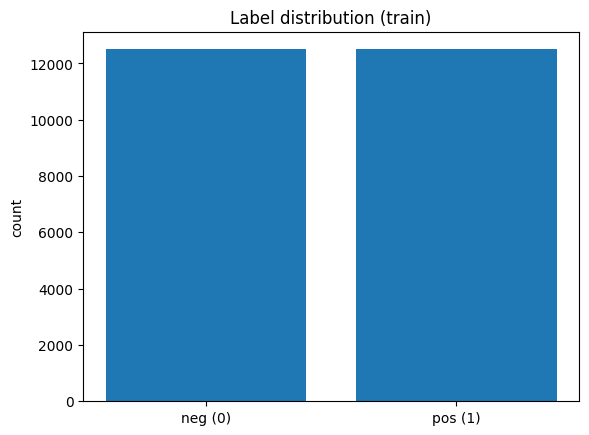

In [319]:
 # Dataset Overview
print(train_df.info())
print(train_df.describe())

# Label Distribution
label_counts=train_df["label"].value_counts().sort_index()
print("\nLabel counts:\n", label_counts)

plt.figure()
plt.bar(["neg (0)", "pos (1)"], [label_counts[0], label_counts[1]])
plt.title("Label distribution (train)")
plt.ylabel("count")
plt.show()

### Review Length Analysis

Mean words: 233
Median words: 174
95th percentile: 598
Max words: 2470


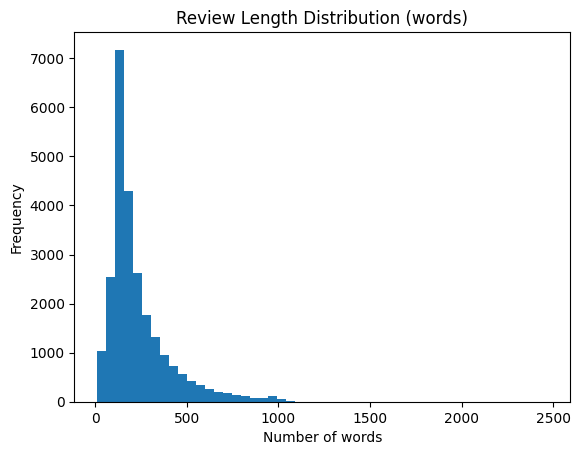

In [320]:
# Review length in words
lengths = train_df["review"].apply(lambda x: len(x.split()))

print("Mean words:", int(lengths.mean()))
print("Median words:", int(lengths.median()))
print("95th percentile:", int(np.percentile(lengths, 95)))
print("Max words:", int(lengths.max()))

plt.figure()
plt.hist(lengths, bins=50)
plt.title("Review Length Distribution (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()


### Sample Reviews

In [321]:
# Print one positive and one negative review

print("----- POSITIVE REVIEW SAMPLE -----\n")
positive_sample = train_df[train_df["label"] == 1]["review"].iloc[0]
print(positive_sample[:1000])  # Print first 1000 characters

print("\n\n----- NEGATIVE REVIEW SAMPLE -----\n")
negative_sample = train_df[train_df["label"] == 0]["review"].iloc[0]
print(negative_sample[:1000])  # Print first 1000 characters


----- POSITIVE REVIEW SAMPLE -----

"Hollywood North" is an euphemism from the movie industry as they went to Canada to make movies because of tax breaks and cheaper costs in a civilized city like Toronto, in this case, later in Vancouver. Peter O'Brian, the director, probably saw a lot of the invaders from California that this movie seems to be the right way to deal with the arriving personalities trying to capitalize on the economics that Canada presented.<br /><br />Needless to say, "Moon Lantern", the successful novel written by a Canadian author is turned into "Flight to Bogota", which has nothing to do with the original film. A great egotistical has-been, Michael Baytes, who is obsessed with what is happening in Iran, is offered the lead part, which turns to be a disaster.<br /><br />The film seems to be saying that too many cooks have spoiled the broth, which seems to be the case with the ultimate product, which is saved by its producer, Bobby Myers. With the help of Sandy Ryan,

### Prepare the Dataset (Shuffle + Train/Val split)

We will split the training data further into training and validation subsets. The way we constructed the dataset, reviews with positive and negative labels are segregated. To ensure that the validation dataset works well, we first need to shuffle the dataset.

We are doing it because the DataFrame was built as, all positives first and all negatives after. For this reason if we split without shuffling, the validation set could end up mostly one class so with meaningless accuracy.

Shuffling ensures both sets are representative.



In [322]:
# Split train data into training and validation sets manually
train_size = int(0.9 * len(train_df))

# Shuffle the dataset
shuffled_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

train_data = shuffled_df.iloc[:train_size]
val_data = shuffled_df.iloc[train_size:]

print("Train split:", train_data.shape)
print("Val split:", val_data.shape)

print("\nTrain label distribution:\n", train_data["label"].value_counts().sort_index())
print("\nVal label distribution:\n", val_data["label"].value_counts().sort_index())


Train split: (22500, 2)
Val split: (2500, 2)

Train label distribution:
 label
0    11247
1    11253
Name: count, dtype: int64

Val label distribution:
 label
0    1253
1    1247
Name: count, dtype: int64


### Testing the Tokenizer

Character-level tokenization, where each character in the text is treated as a token, is less efficient and may result in larger input sizes, impacting the performance of transformer models.

To address this, we will use Hugging Face's AutoTokenizer, a robust and efficient class designed for tokenizing text based on pretrained models. Specifically, we will utilize the bert-base-uncased tokenizer, which applies subword tokenization. Subword tokenization involves two steps:

Subword Splitting: Words are split into smaller components (subwords) based on a predefined vocabulary. For example:

- Input: "unhappiness"
- Subword Splits: ['un', 'happiness']
- Token Conversion: Each subword is then converted into a numerical token ID. For example:

- Subword Splits: ['un', 'happiness']
- Token IDs: [1011, 24123] (values are illustrative and depend on the tokenizer vocabulary).

So now We will initialize Hugging Face’s tokenizer (bert-base-uncased) and test it on a few sample reviews.

About the bert-base-uncased Tokenizer
The bert-base-uncased tokenizer, developed by Google researchers, is part of the BERT model family. This tokenizer is associated with the bert-base-uncased model, which has been widely used for tasks such as sentiment analysis, question answering, and text classification. The tokenizer ensures all text is converted to lowercase and accents are removed, reducing vocabulary size and improving generalization. Example:

- input: "I Love Transformers."
- Subword Splits: ['i', 'love', 'trans', '##formers', '.']

Using the AutoTokenizer Class
The AutoTokenizer class in the Hugging Face Transformers library provides a seamless way to load tokenizers for various pretrained models. It automatically selects the correct tokenizer configuration based on the model name.

With all this we want to confirm that the tokenization works, that we check output keys such as input_ids, attention_mask and that we verify the MAX_LENGTH=128 behavior




In [323]:
from transformers import AutoTokenizer

# Max token length (Udacity requirement)
MAX_LENGTH = 128

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Take sample inputs from the dataset
sample_texts = train_data["review"].sample(3, random_state=42).tolist()

# Tokenize sample inputs
tokenized_samples = tokenizer(sample_texts, truncation=True, padding="max_length", max_length=128, return_tensors="pt")

print(tokenized_samples)
print("\ninput_ids shape:", tokenized_samples["input_ids"].shape)
print("attention_mask shape:", tokenized_samples["attention_mask"].shape)

{'input_ids': tensor([[  101,  2074,  1996,  2785,  1997,  3185,  1045,  2293,  1012,  2070,
          2200,  2204,  2329,  5889,  2004,  2092,  2004,  1996,  2028,  1998,
          2069, 10666,  2962,  1012,  6615, 12517,  5349,  1006,  2962,  1007,
          3040,  7699, 17708,  2015,  1037,  2092,  5161,  2177,  1997,  2111,
          1005,  1055,  3268,  1010,  2652,  2006,  2037, 25737,  7368,  2000,
          8145,  6322,  2000,  4339,  1037,  4028,  6547,  2338,  1012,  2016,
          3248,  1996,  2931, 18224, 15069,  3243,  2092,  2096,  2478,  2014,
         20851,  3348,  5574,  2000, 13359,  2135, 17279,  2054,  2071,  2022,
          2641,  2028,  1997,  1996,  7209,  2304, 24835,  1012, 12517,  5349,
          2003,  2224,  2000,  2601,  3182,  2306,  2554,  1998, 10350,  2112,
         20060,  1999,  6517,  9626,  6499,  5428, 10074, 27655,  2015,  1999,
          1996,  1005,  2196,  3942,  2044,  2601,  1005,  2217,  1997,  2237,
          1012,  2013,  1996,  2927,  

## Implement a DataLoader in PyTorch

In this section, I will implement a custom dataset class and use it to create a DataLoader in PyTorch for feeding data into the model during training. PyTorch simplifies this process by providing the Dataset and DataLoader classes, which handle batching, shuffling, and preprocessing, allowing you to focus on the model architecture and training.

To start, I will create a custom dataset class for the IMDB dataset, which will process and return tokenized inputs along with their corresponding labels. This class will use a tokenizer to preprocess the raw text data.


 ### Define a Custom Dataset Class

 The custom dataset class will inherit from torch.utils.data.Dataset and include the following features:

- Initialization (__init__):

Accepts raw text and label data, along with a tokenizer and a maximum sequence length.
The tokenizer is used to preprocess the text data into tokenized inputs.
The maximum sequence length ensures that all tokenized inputs are of uniform length.
- Length (__len__):

Returns the total number of data samples in the dataset.
- Item Retrieval (__getitem__):

Retrieves a single data point by index.
Preprocesses the text using the tokenizer to create tokenized input IDs.
Returns the tokenized input IDs and the corresponding label for the given index.

In [324]:
MAX_LENGTH = 128

class IMDBDataset(Dataset):
    """
    A custom PyTorch Dataset for the IMDB dataset.

    This class preprocesses text data using a tokenizer and returns tokenized inputs
    along with their corresponding labels for sentiment analysis.

    Attributes:
        data (pd.DataFrame): A DataFrame containing text and label columns.
        tokenizer (transformers.PreTrainedTokenizer): The tokenizer used for preprocessing text.
        max_length (int): Maximum length for tokenized sequences.
    """
    def __init__(self, data, tokenizer, max_length=MAX_LENGTH):
        """
        Initialize the dataset.

        Args:
            data (pd.DataFrame): A DataFrame with columns `review` (text) and `label` (target).
            tokenizer (transformers.PreTrainedTokenizer): The tokenizer to preprocess the text.
            max_length (int, optional): Maximum token sequence length. Defaults to 128.
        """
         # Store the dataframe and tokenizer
        self.data = data.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        """
        Return the total number of samples in the dataset.

        Returns:
            int: Number of samples.
        """
        # Number of rows in the dataframe
        return len(self.data)

    def __getitem__(self, idx):
        """
        Retrieve a single data point by index and preprocess it.

        Args:
            idx (int): Index of the data point to retrieve.

        Returns:
            torch.Tensor: Tokenized input IDs for the text.
            int: Label corresponding to the text.
        """
        # Get the text and label for this index
        text = self.data.loc[idx, "review"]
        label = int(self.data.loc[idx, "label"])

        # Tokenize the text (returns dict of tensors with shape (1, MAX_LENGTH))
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        # Squeeze batch dimension -> (MAX_LENGTH,)
        input_ids = encoding["input_ids"].squeeze(0)

        return input_ids, label


### Initialize the Dataset
Once the IMDBDataset class is defined, we can initialize it directly with the training and validation DataFrames.

In [325]:
# Initialize the datasets
train_dataset = IMDBDataset(train_data, tokenizer)
val_dataset = IMDBDataset(val_data, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

### Create a DataLoader

The DataLoader class in PyTorch helps manage batches of data during training. We will use it to create training and validation data loaders.

In [326]:
from torch.utils.data import DataLoader

# Define batch size
BATCH_SIZE = 32

# Create DataLoader instances
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Validate asserts


In [327]:
assert len(train_dataset) == 22500, "Train dataset length mismatch!"
assert len(val_dataset) == 2500, "Validation dataset length mismatch!"
assert len(test_dataset) == 25000, "Test dataset length mismatch!"

import numpy as np

# Check the first item in the train dataset
input_ids, label = train_dataset[0]
assert isinstance(input_ids, torch.Tensor), "Input IDs should be a torch.Tensor!"
assert isinstance(label, (int, np.integer)), "Label should be an integer or int-like!"

# Ensure the input IDs tensor has the correct shape
assert input_ids.shape[0] == train_dataset.max_length, "Input IDs tensor has incorrect length!"

print("IMDBDataset and DataLoaders validated")

IMDBDataset and DataLoaders validated


## Customize the Transformer Architecture
In this section, I will customize the transformer architecture to suit the task of binary classification. 


### Config Dictionary
Your config dictionary bundles all hyperparameters and model settings in one place. Below is the config that we will use in our model:

In [328]:
config = {
    "vocabulary_size": tokenizer.vocab_size,  # e.g., ~30522 for bert-base-uncased
    "num_classes": 2,                         # binary classification (pos/neg)
    "d_embed": 128,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 4,
    "head_size": 32,  # 4 heads * 32 = 128 -> matches d_embed
    "dropout_rate": 0.1,
    "use_bias": True
}

Key Config Parameters:

vocabulary_size: The total number of tokens in your vocabulary.

num_classes: The number of classes for the classification head (2 = binary).

d_embed: Dimensionality of embeddings (and hidden layers).

context_size: Maximum sequence length for each input.

layers_num: Number of stacked transformer blocks.

heads_num: Number of attention heads in multi-head attention.

head_size: Dimension of each attention head (must satisfy heads_num * head_size = d_embed).

dropout_rate: Probability of dropping units during training to reduce overfitting.

use_bias: Whether linear layers should have bias terms.

### Class Definitions
Below are the class definitions you will work with. These classes form the core components of the transformer model. 



AttentionHead

In [329]:
import torch.nn as nn
import math

class AttentionHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.K_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.V_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])

        self.dropout = nn.Dropout(config["dropout_rate"])

        casual_attention_mask = torch.tril(torch.ones(config["context_size"], config["context_size"]))
        self.register_buffer('casual_attention_mask', casual_attention_mask)

    def forward(self, input):
        batch_size, tokens_num, d_embed = input.shape
        Q = self.Q_weights(input)  # (B, T, head_size)
        K = self.K_weights(input)  # (B, T, head_size)
        V = self.V_weights(input)  # (B, T, head_size)

        # Q @ K^T => (B, T, T)
        attention_scores = Q @ K.transpose(1, 2)

        # Casual Mask
        attention_scores = attention_scores.masked_fill(
            self.casual_attention_mask[:tokens_num, :tokens_num] == 0,
            float('-inf')
        )
        attention_scores = attention_scores / math.sqrt(K.shape[-1])
        attention_scores = torch.softmax(attention_scores, dim=-1)
        attention_scores = self.dropout(attention_scores)

        return attention_scores @ V

Here we use a dummy input aligned with our config:

Batch size = BATCH_SIZE (32)

Sequence length = config["context_size"] (128)

Embedding dimension = config["d_embed"] (128)


In [330]:
# Instantiate the AttentionHead
attention_head = AttentionHead(config).to(device)

# Create a dummy input of shape (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
attention_output = attention_head(dummy_input)
print("AttentionHead output shape:", attention_output.shape)

AttentionHead output shape: torch.Size([32, 128, 32])


MultiHeadAttention

In [331]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)

        self.linear = nn.Linear(config["heads_num"] * config["head_size"], config["d_embed"])
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        heads_outputs = [head(input) for head in self.heads]
        x = torch.cat(heads_outputs, dim=-1)  # (B, T, heads_num * head_size)
        x = self.linear(x)                   # (B, T, d_embed)
        x = self.dropout(x)
        return x

In [332]:
# Instantiate MultiHeadAttention
multi_head_attention = MultiHeadAttention(config).to(device)

# Same dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
mha_output = multi_head_attention(dummy_input)
print("MultiHeadAttention output shape:", mha_output.shape)

MultiHeadAttention output shape: torch.Size([32, 128, 128])


FeedForward

In [333]:
class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(config["d_embed"], 4 * config["d_embed"]),
            nn.GELU(),
            nn.Linear(4 * config["d_embed"], config["d_embed"]),
            nn.Dropout(config["dropout_rate"])
        )

    def forward(self, input):
        return self.linear_layers(input)

In [334]:
# Instantiate FeedForward
feed_forward = FeedForward(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
ff_output = feed_forward(dummy_input)
print("FeedForward output shape:", ff_output.shape)

FeedForward output shape: torch.Size([32, 128, 128])


Block

In [335]:
class Block(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])

        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input):
        x = input
        x = x + self.multi_head(self.layer_norm_1(x))
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [336]:
# Instantiate a single Block
block = Block(config).to(device)

# Dummy input: (32, 128, 128)
dummy_input = torch.randn(BATCH_SIZE, config["context_size"], config["d_embed"]).to(device)

# Forward pass
block_output = block(dummy_input)
print("Block output shape:", block_output.shape)

Block output shape: torch.Size([32, 128, 128])


### DemoGPT
Below is the starter code for the DemoGPT class, which implements the core of a transformer model tailored for a binary classification task. This implementation builds on the foundation of a transformer architecture and includes the necessary modifications to adapt it for classification.

Key Changes for Binary Classification
To adapt the transformer for classification, the following changes are required:

Add a Classification-Specific Output Layer:

- The model needs a linear layer to map the final pooled embeddings to the number of classes.
- The classification head is implemented using torch.nn.Linear with:
- in_features set to d_embed (the embedding dimension).
- out_features set to num_classes (the number of classes, 2 for binary classification).
- bias set to False (optional; bias can be excluded to slightly simplify computations).

Implement a Pooling Mechanism:

- Transformers output embeddings for each token in the input sequence. For classification, these token-level embeddings need to be condensed into a single vector.

- A mean pooling operation is applied using torch.mean across the time dimension (dim=1) to aggregate token-level embeddings into a single representation vector.

In [337]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        """
        Initialize the DemoGPT class with configuration parameters.

        Args:
        - config (dict): Configuration dictionary with the following keys:
            - "vocabulary_size": Size of the vocabulary.
            - "d_embed": Dimensionality of the embedding vectors.
            - "context_size": Maximum sequence length (context size).
            - "layers_num": Number of transformer layers.
            - "num_classes": Number of output classes (2 for binary classification).
        """
        super().__init__()
        # Token embedding layer: Maps token indices to embedding vectors.
        self.token_embedding_layer = nn.Embedding(config["vocabulary_size"], config["d_embed"])
        
        # Positional embedding layer: Adds positional information to the embeddings.
        self.positional_embedding_layer = nn.Embedding(config["context_size"], config["d_embed"])
        
        # Transformer layers: Stacked sequence of transformer blocks.
        blocks = [Block(config) for _ in range(config["layers_num"])]
        self.layers = nn.Sequential(*blocks)
        
        # Layer normalization: Applied to stabilize training.
        self.layer_norm = nn.LayerNorm(config["d_embed"])
        
        # Implement classification output layer - Maps pooled embeddings to class logits.
        self.classifier = nn.Linear(config["d_embed"], config["num_classes"], bias=False)

    def forward(self, token_ids):
        """
        Forward pass of the model.

        Args:
        - token_ids (torch.Tensor): Input token indices of shape (B, T), 
                                    where B is the batch size, and T is the sequence length.
        
        Returns:
        - logits (torch.Tensor): Output logits of shape (B, num_classes).
        """
        batch_size, tokens_num = token_ids.shape

        # Step 1: Create embeddings for tokens and their positions
        x = self.token_embedding_layer(token_ids)  # Shape: (B, T, d_embed)
        positions = torch.arange(tokens_num, device=token_ids.device)  # Shape: (T,)
        pos_embed = self.positional_embedding_layer(positions)  # Shape: (T, d_embed)
        x = x + pos_embed.unsqueeze(0)  # Add positional embeddings to token embeddings
        
        # Step 2: Pass embeddings through transformer layers
        x = self.layers(x)  # Shape: (B, T, d_embed)
        x = self.layer_norm(x)  # Normalize across the feature dimension
        
        # Step 3: TODO: Apply mean pooling across the time dimension  # Shape: (B, d_embed)
        pooled = torch.mean(x, dim=1)          # (B, d_embed)
        
        # Step 4: TODO: Generate logits for classification  # Shape: (B, num_classes)
        logits = self.classifier(pooled)       # (B, num_classes)
        
        return logits

In [338]:
# Instantiate the model
demo_gpt = DemoGPT(config).to(device)

# Suppose we have a batch of size 32, each with a sequence length of 128
dummy_token_ids = torch.randint(
    0, config["vocabulary_size"], 
    (BATCH_SIZE, config["context_size"])
).to(device)

# Forward pass
logits = demo_gpt(dummy_token_ids)

print("DemoGPT output shape:", logits.shape)
print("Logits sample:\n", logits[:2])  # Print first two examples' logits

DemoGPT output shape: torch.Size([32, 2])
Logits sample:
 tensor([[-0.1070,  0.0589],
        [-0.0957, -0.0083]], grad_fn=<SliceBackward0>)


In [339]:
# Assert that the number of logits matches the number of classes
assert logits.size(1) == config["num_classes"], (
    f"Expected number of classes {config['num_classes']}, "
    f"but got {logits.size(1)}"
)

# Assert that the batch size of the output matches the input batch size
assert logits.size(0) == BATCH_SIZE, (
    f"Expected batch size {BATCH_SIZE}, "
    f"but got {logits.size(0)}"
)

## Implement Accuracy Calculation Method

In this section, you will learn how to calculate the validation accuracy for the transformer model on the IMDB dataset. Validation accuracy provides a performance metric that helps assess how well the model generalizes to unseen data during training.

1. Overview
The function to calculate validation accuracy will:

- Evaluate the model on the validation dataset.
- Generate predictions for each batch.
- Compare predictions with the true labels.
- Compute the percentage of correctly classified examples.

2. Key Points
- Evaluation Mode: Calling model.eval() ensures that dropout and other training-specific layers are disabled during evaluation.
- No Gradients: The torch.no_grad() context disables gradient computation, reducing memory usage and speeding up validation.
- Predictions: torch.argmax(logits, dim=1) retrieves the index of the highest logit for each sample, which corresponds to the predicted class label.
- Accuracy Calculation: The function computes the fraction of correct predictions out of the total number of samples, then multiplies by 100 to express it as a percentage.

After calculating the validation accuracy, we will incorporate this function into our training loop. Typically, we would call calculate_accuracy at the end of each epoch or after a specific number of training steps. Monitoring validation accuracy over time helps us track performance gains and identify potential overfitting or underfitting issues.

In [340]:
def calculate_accuracy(model, data_loader, device):
    """
    Calculate the accuracy of the model on the validation dataset.

    Args:
        model (torch.nn.Module): The trained transformer model.
        data_loader (torch.utils.data.DataLoader): DataLoader for the validation dataset.
        device (torch.device): Device to run the model (e.g., 'cuda' or 'cpu').

    Returns:
        float: Validation accuracy as a percentage.
    """
    model.eval()
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for input_ids, labels in data_loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)

            logits = model(input_ids)  # (B, 2)
            preds = torch.argmax(logits, dim=1)  # (B,)

            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    accuracy = (total_correct / total_samples) * 100
    return accuracy

In [341]:
model = DemoGPT(config).to(device)

In [342]:
validation_accuracy = calculate_accuracy(model, val_loader, device)
print(f"Validation Accuracy: {validation_accuracy:.2f}%")

Validation Accuracy: 50.76%
